# Introduction to LangGraph

Required packages
- langchain
- langgraph
- Depending on which LLM model you use, need to install corresponding package. E.g., openai models: `langchain-openai`

## References
- [LangGraph Quickstart](https://docs.langchain.com/oss/python/langgraph/quickstart)

## Define Tools

In [1]:
from langchain.tools import tool

# Define tools
@tool(description="Multiplies two integers", parse_docstring=False)
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool(parse_docstring=True)
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool(parse_docstring=True)
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

## Define State

In [2]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

## Define Node and Router

- node defines functionailites.
- router decides which node to go.

In [ ]:
from enum import StrEnum
from langchain.messages import SystemMessage, ToolMessage
from langchain.chat_models import init_chat_model
from typing import Literal
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


class NodeName(StrEnum):
    llm_node = "llm_node"
    tool_node = "tool_node"

# need to load OPENAI_API_KEY
load_dotenv(r"notebooks/data-science/LangGraph.ipynb/.env")
# init the LLM model
model = init_chat_model(
    "openai:gpt-5-mini",
    temperature=0,
)
# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name: dict[str, callable] = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

def llm_node(state: dict):
    """
    Call LLM. LLM decides whether to call a tool or not. We can detect LLM's intention by checking `tool_calls` attribute
    and then decide which node to go as next step. This will be done by a router function `should_continue` defined below.
    """
    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}



# version 1
def should_continue(state: MessagesState) -> Literal[NodeName.tool_node, END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return NodeName.tool_node

    # Otherwise, we stop (reply to the user)
    return END

# version 2
def should_call_tool(state: MessagesState) -> bool:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return True

    # Otherwise, we stop (reply to the user)
    return False

## Build Graph

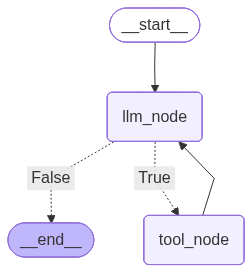

In [8]:
from IPython.display import Image, display
from langchain.messages import HumanMessage

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node(NodeName.llm_node, llm_node)
agent_builder.add_node(NodeName.tool_node, tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, NodeName.llm_node)
agent_builder.add_conditional_edges(
    NodeName.llm_node,
    should_call_tool,
    {True: NodeName.tool_node, False: END},
)
agent_builder.add_edge(NodeName.tool_node, NodeName.llm_node)

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [9]:
# Invoke
msg_content = "Add 3 and 4."
messages = [HumanMessage(content=msg_content)]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_9szWkV5L0L98ggxEYXsPQJPX)
 Call ID: call_9szWkV5L0L98ggxEYXsPQJPX
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

7


In [33]:
messages["llm_calls"]

2

In [34]:
messages["messages"]

[HumanMessage(content='Add 3 and 4.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 216, 'total_tokens': 306, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlZ9gGIevcxz3V0zR5JBZ0WAyc12c', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7de9-91ad-7fe3-8178-0087469974e3-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_9szWkV5L0L98ggxEYXsPQJPX', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 216, 'output_tokens': 90, 'total_tokens': 306, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

# Other workflows

In [36]:
# Schema for structured output
from pydantic import BaseModel, Field


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )

model = init_chat_model(
    "openai:gpt-5-mini",
    temperature=0,
)
# Augment the LLM with schema for structured output
structured_llm = model.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")


In [42]:
for x in output:
    print(f"{x[0]}: {x[1]}")

search_query: coronary artery calcium score and high cholesterol: association between CAC and LDL cholesterol, predictive value for coronary events, how CAC modifies ASCVD risk, evidence (MESA study), and guideline recommendations for using CAC to guide statin therapy
justification: This query targets the link between coronary artery calcium (CAC) score and high cholesterol (particularly LDL), looks for evidence about how CAC correlates with atherosclerotic risk independent of lipid levels, and retrieves guideline recommendations and key studies (e.g., MESA, ACC/AHA) that inform clinical use of CAC to guide statin decisions.
